In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

plt.rcParams["font.family"] = "serif"

In [46]:
dtype_to_bytes = {
    "float64": 8,
    "float32": 4,
    "float16": 2,
    "bfloat16": 2,
}

In [47]:
df = pd.read_csv("../results/benchmark_batched_gemv.csv")
df["times (ms)"] = df["times (ms)"].apply(ast.literal_eval)
df["time (ms)"] = df["times (ms)"].apply(min)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms)
0,10485,80,float16,float64,custom,"[0.12495648384094238, 0.12500927925109864, 0.1...",0.001337,0.118247
1,10485,80,float16,float64,torch,"[0.12133119583129882, 0.124136962890625, 0.121...",2.403678,0.121331
2,10228,81,float16,float64,custom,"[0.11840448379516602, 0.11703071594238282, 0.1...",0.001347,0.117019
3,10228,81,float16,float64,torch,"[0.14195712089538573, 0.1421292781829834, 0.14...",2.410250,0.141957
4,9980,82,float16,float64,custom,"[0.12306207656860352, 0.11918016433715821, 0.1...",0.001351,0.119171
...,...,...,...,...,...,...,...,...
95,4160,127,float16,float64,torch,"[0.14186880111694336, 0.14262816429138184, 0.1...",2.404277,0.141869
96,4096,128,float16,float64,custom,"[0.12100383758544922, 0.11615839958190918, 0.1...",0.001674,0.116125
97,4096,128,float16,float64,torch,"[0.10127967834472656, 0.10182944297790528, 0.1...",2.401939,0.101280
98,4032,129,float16,float64,custom,"[0.12367327690124512, 0.11831392288208008, 0.1...",0.001689,0.118290


In [48]:
def throughput(n, k, time_ms, mat_dtype, vec_dtype):
    mat_el_bytes = dtype_to_bytes[mat_dtype]
    vec_el_bytes = dtype_to_bytes[vec_dtype]
    total_bytes = n * k * k * mat_el_bytes + n * k * vec_el_bytes + n * k * vec_el_bytes
    return total_bytes / (time_ms / 1000) / 1e9

In [49]:
def flops(n, k, time_ms):
    total_flops = 2 * n * k * k
    return total_flops / (time_ms / 1000) / 1e9

In [50]:
df["throughput"] = df.apply(
    lambda row: throughput(
        n=row["n"],
        k=row["k"],
        time_ms=row["time (ms)"],
        mat_dtype=row["A_dtype"],
        vec_dtype=row["b_dtype"],
    ),
    axis=1,
)
df["GFlops"] = df.apply(
    lambda row: flops(n=row["n"], k=row["k"], time_ms=row["time (ms)"]),
    axis=1,
)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms),throughput,GFlops
0,10485,80,float16,float64,custom,"[0.12495648384094238, 0.12500927925109864, 0.1...",0.001337,0.118247,1248.474422,1134.976748
1,10485,80,float16,float64,torch,"[0.12133119583129882, 0.124136962890625, 0.121...",2.403678,0.121331,1216.742314,1106.129377
2,10228,81,float16,float64,custom,"[0.11840448379516602, 0.11703071594238282, 0.1...",0.001347,0.117019,1260.204435,1146.927632
3,10228,81,float16,float64,torch,"[0.14195712089538573, 0.1421292781829834, 0.14...",2.410250,0.141957,1038.815827,945.439124
4,9980,82,float16,float64,custom,"[0.12306207656860352, 0.11918016433715821, 0.1...",0.001351,0.119171,1236.077175,1126.203648
...,...,...,...,...,...,...,...,...,...,...
95,4160,127,float16,float64,torch,"[0.14186880111694336, 0.14262816429138184, 0.1...",2.404277,0.141869,1005.481113,945.897047
96,4096,128,float16,float64,custom,"[0.12100383758544922, 0.11615839958190918, 0.1...",0.001674,0.116125,1228.036985,1155.799516
97,4096,128,float16,float64,torch,"[0.10127967834472656, 0.10182944297790528, 0.1...",2.401939,0.101280,1408.044914,1325.218743
98,4032,129,float16,float64,custom,"[0.12367327690124512, 0.11831392288208008, 0.1...",0.001689,0.118290,1204.797945,1134.444780


In [51]:
def plot_throughput(ax, mat_dtype: str, vec_dtype: str, labels: bool = False):
    max_tput = df[
        (df.A_dtype == mat_dtype) & (df.b_dtype == vec_dtype) & (df.k <= 128)
    ].pivot_table(values="throughput", columns="algorithm", index="k", aggfunc="max")

    title = f"{mat_dtype} $\\times$ {vec_dtype}"
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_xlabel("matrix size k")
    ax.set_ylabel("throughput (GB/s)")

    ax.set_xlim(left=0, right=130)

    ax.grid(which="both", linestyle="--", linewidth=0.5, color="grey")

    ax.scatter(
        x=max_tput.index,
        y=max_tput["custom"],
        marker="^",
        label="Our implementation" if labels else None,
        s=13,
        zorder=3,
        facecolors="none",
        edgecolors="tab:blue",
    )
    ax.scatter(
        x=max_tput.index,
        y=max_tput["torch"],
        marker="o",
        label="PyTorch" if labels else None,
        s=13,
        zorder=2,
        facecolors="none",
        edgecolors="tab:orange",
    )
    ax.axhline(
        y=2039,
        color="red",
        linestyle="--",
        label="A100 bandwidth (2,039GB/s)" if labels else None,
    )

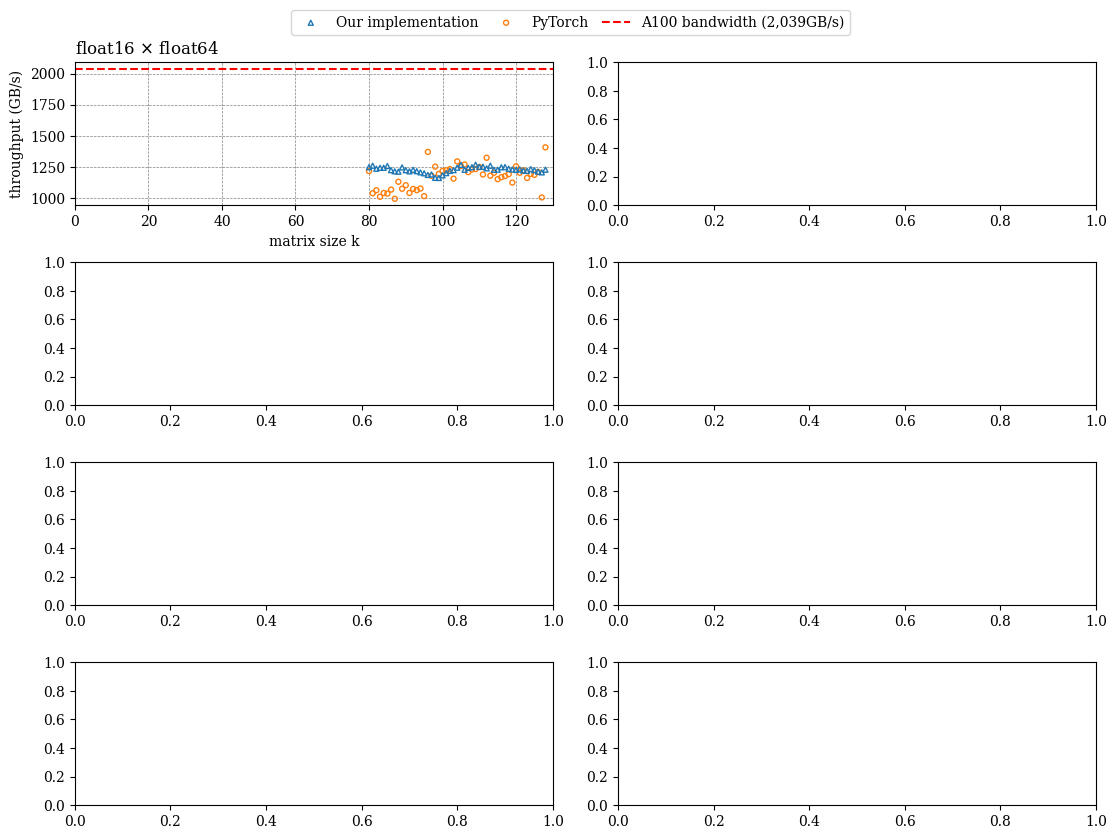

In [52]:
fig, axes = plt.subplots(4, 2, figsize=(11, 8))
fig.tight_layout(pad=1.0, h_pad=2.0)
for i, mat_dtype in enumerate(df.A_dtype.unique()):
    for j, vec_dtype in enumerate(df.b_dtype.unique()):
        if mat_dtype == "float64" and vec_dtype == "float32":
            continue
        plot_throughput(axes[i, j], mat_dtype, vec_dtype, labels=(i == 0 and j == 0))

fig.legend(ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.05), columnspacing=1)
# fig.savefig("../docs/thesis-media/matrix_vec_tput.svg", bbox_inches="tight")

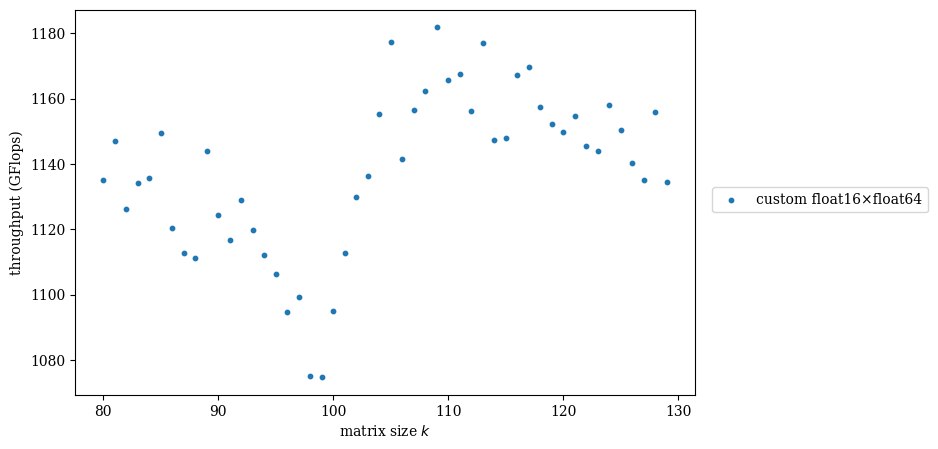

In [53]:
max_tput = df.pivot_table(
    values="GFlops",
    columns=["algorithm", "A_dtype", "b_dtype"],
    index="k",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel("matrix size $k$")
ax.set_ylabel("throughput (GFlops)")

for col in max_tput.columns:
    if col[2] == "float64" and col[0] == "custom":
        ax.scatter(
            max_tput.index,
            max_tput[col],
            label=col[0] + " " + col[1] + "×" + col[2],
            s=10,
        )

fig.legend(loc="right", bbox_to_anchor=(1.2, 0.5))